# 🤖 PPO-Eureka Training on LunarLander-v2
### Eureka Assignment — LLM-Generated Reward via llama-3.3-70b-versatile

This notebook implements the **Eureka loop**:
1. llama-3.3-70b-versatile reads the LunarLander environment code
2. Claude writes a `compute_reward()` function
3. We run a short PPO training to evaluate that reward
4. We feed the score back to Claude — it revises the reward
5. Repeat for N iterations → pick the best reward
6. Train full PPO with the best reward → save GIF checkpoints

**What this notebook does:**
- Runs the Eureka reward-generation loop (3 iterations, ~3 API calls)
- Trains final PPO-Eureka with the best LLM-generated reward
- Saves GIF snapshots at checkpoints: episode 1, 5, 10, 25, 50, 100, 200, 500
- Saves all generated reward functions, metrics, and models
- Zips everything for download

**Prerequisites:** You need a Grok API key.

**Runtime:** ~35–50 minutes on Colab

## 📦 Step 1: Install Dependencies

In [1]:
!pip install stable-baselines3[extra] gymnasium[box2d] imageio anthropic --quiet
!apt-get install -y xvfb python3-opengl > /dev/null 2>&1
!pip install pyvirtualdisplay --quiet
!pip install stable-baselines3[extra] gymnasium[box2d] imageio groq --quiet
print('✅ All dependencies installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.7/627.7 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.4 MB/s eta 0:00:00
✅ All dependencies installed!


## 🖥️ Step 2: Set Up Virtual Display

In [2]:
from pyvirtualdisplay import Display

display = Display(visible=0, size=(600, 400))
display.start()
print('✅ Virtual display started!')

✅ Virtual display started!


## 🔑 Step 3: Enter Your Groq API Key

You can get a key at https://groq.com/ — the Eureka loop only makes ~3–5 API calls total, so cost is minimal (see the cost breakdown at the end of this notebook).

In [4]:
from groq import Groq
from getpass import getpass

GROQ_API_KEY = getpass('🔑 Enter your Groq API key: ')
client = Groq(api_key=GROQ_API_KEY)
print('✅ Groq client initialized!')

🔑 Enter your Groq API key: ··········
✅ Groq client initialized!


## 📁 Step 4: Imports & Directory Setup

In [6]:
import json
import time
import shutil
import textwrap
import traceback
import re
import numpy as np
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import matplotlib
import os
matplotlib.use('Agg')

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy
from IPython.display import Image, display as ipy_display

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# ── Output directories ──────────────────────────────────────────────────────
BASE_DIR     = '/content/ppo_eureka_results'
GIF_DIR      = f'{BASE_DIR}/gifs'
MODEL_DIR    = f'{BASE_DIR}/models'
METRICS_DIR  = f'{BASE_DIR}/metrics'
PLOTS_DIR    = f'{BASE_DIR}/plots'
REWARDS_DIR  = f'{BASE_DIR}/reward_functions'  # Saves each LLM reward fn

for d in [BASE_DIR, GIF_DIR, MODEL_DIR, METRICS_DIR, PLOTS_DIR, REWARDS_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ Directories created!')

✅ Directories created!


## ⚙️ Step 5: Configuration

In [7]:
CONFIG = {
    # Environment
    'env_id'                : 'LunarLander-v3',
    'seed'                  : 42,

    # Eureka loop settings
    'eureka_iterations'     : 3,       # Number of LLM reward refinement iterations
    'eureka_eval_timesteps' : 80_000,  # Short training run to evaluate each reward
    'eureka_eval_episodes'  : 20,      # Episodes for scoring each reward candidate
    'grok_model'          : 'llama-3.3-70b-versatile',
    'grok_max_tokens'     : 1500,    # Max output tokens per API call

    # PPO hyperparameters (same as standard PPO for fair comparison)
    'learning_rate'         : 3e-4,
    'n_steps'               : 1024,
    'batch_size'            : 64,
    'n_epochs'              : 4,
    'gamma'                 : 0.999,
    'gae_lambda'            : 0.98,
    'clip_range'            : 0.2,
    'ent_coef'              : 0.01,
    'vf_coef'               : 0.5,
    'max_grad_norm'         : 0.5,
    'policy'                : 'MlpPolicy',

    # Full training
    'total_timesteps'       : 1_000_000,

    # GIF settings
    'gif_fps'               : 30,
    'gif_max_steps'         : 500,

    # Checkpoint episodes
    'checkpoint_episodes'   : [5, 25, 100, 300, 500, 750, 1000, 1500, 2000, 2500],
}

print('✅ Configuration set!')
print(f'   grok model       : {CONFIG["grok_model"]}')
print(f'   Eureka iterations  : {CONFIG["eureka_iterations"]}')
print(f'   Eval timesteps/run : {CONFIG["eureka_eval_timesteps"]:,}')
print(f'   Full training      : {CONFIG["total_timesteps"]:,} timesteps')

✅ Configuration set!
   grok model       : llama-3.3-70b-versatile
   Eureka iterations  : 3
   Eval timesteps/run : 80,000
   Full training      : 1,000,000 timesteps


## 🌍 Step 6: Custom LunarLander Environment with Pluggable Reward

This is the key architectural piece. Instead of using LunarLander's built-in reward, we wrap it so we can **swap in any reward function** — either our handcrafted one or whichever Grok generates. The same environment, same physics, just a different reward signal.

In [8]:
class LunarLanderCustomReward(gym.Wrapper):
    """
    Wraps LunarLander-v2 and replaces the built-in reward with a
    pluggable compute_reward() function.

    The reward function receives:
        obs        : np.ndarray (8,) — current observation AFTER the step
        action     : int — discrete action taken (0=do nothing, 1=left engine,
                     2=main engine, 3=right engine)
        next_obs   : np.ndarray (8,) — same as obs (included for consistency)
        terminated : bool — True if lander crashed or landed
        truncated  : bool — True if episode timed out
        info       : dict — contains 'shaping' with the original shaped reward

    Observation layout (obs[i]):
        obs[0]  x position          (0 = centre of pad)
        obs[1]  y position          (0 = ground level)
        obs[2]  x velocity
        obs[3]  y velocity
        obs[4]  angle              (0 = upright)
        obs[5]  angular velocity
        obs[6]  left  leg contact  (1.0 if touching ground)
        obs[7]  right leg contact  (1.0 if touching ground)
    """

    def __init__(self, reward_fn=None):
        env = gym.make('LunarLander-v3')
        super().__init__(env)
        # If no custom reward provided, use the built-in one
        self.reward_fn = reward_fn

    def step(self, action):
        obs, original_reward, terminated, truncated, info = self.env.step(action)

        if self.reward_fn is not None:
            try:
                reward = float(self.reward_fn(
                    obs       = obs,
                    action    = action,
                    next_obs  = obs,
                    terminated= terminated,
                    truncated = truncated,
                    info      = info
                ))
                # Safety clamp — prevent reward explosion that could crash training
                reward = np.clip(reward, -1000.0, 1000.0)
            except Exception:
                # If reward function crashes, fall back to original
                reward = original_reward
        else:
            reward = original_reward

        return obs, reward, terminated, truncated, info


# ── Environment source code that we will give to Grok as context ────────────
# This is what Grok reads to understand the environment before writing rewards.
ENVIRONMENT_DESCRIPTION = """
ENVIRONMENT: LunarLander-v3 (OpenAI Gymnasium)

GOAL: Land a rocket between two flags on a flat pad. The episode ends when
the lander crashes, lands safely, or 1000 steps pass.

OBSERVATION SPACE (8 continuous values, all roughly in [-1, 1]):
  obs[0]  x position          — 0.0 is directly above the landing pad
  obs[1]  y position          — 0.0 is at ground level
  obs[2]  x velocity          — negative = moving left, positive = moving right
  obs[3]  y velocity          — negative = falling, positive = rising
  obs[4]  angle               — 0.0 = perfectly upright, positive = tilted right
  obs[5]  angular velocity    — rate of rotation
  obs[6]  left  leg contact   — 1.0 if leg is touching ground, else 0.0
  obs[7]  right leg contact   — 1.0 if leg is touching ground, else 0.0

ACTION SPACE (4 discrete actions):
  0  — do nothing (no thruster)
  1  — fire left orientation engine
  2  — fire main engine (upward thrust)
  3  — fire right orientation engine

TERMINATION CONDITIONS:
  terminated=True  if lander crashes (body hits ground) OR lands safely
  truncated=True   if 1000 steps elapsed without landing or crashing
  A safe landing requires both legs touching (obs[6]=1 and obs[7]=1)
  and the lander nearly stationary near the pad.

WRAPPER FUNCTION SIGNATURE (what you must implement):
  def compute_reward(obs, action, next_obs, terminated, truncated, info) -> float:
      # obs and next_obs are numpy arrays of shape (8,)
      # action is an int in {0, 1, 2, 3}
      # terminated, truncated are bools
      # info is a dict (usually empty, can be ignored)
      # Return a single float — the reward for this step
      ...

WHAT A GOOD REWARD FUNCTION SHOULD ENCOURAGE:
  1. Moving towards the landing pad (reducing |obs[0]| and obs[1])
  2. Slowing down as it approaches (reducing speed when near pad)
  3. Staying upright (keeping obs[4] close to 0)
  4. Making leg contact with the ground (obs[6] and obs[7] = 1)
  5. Not wasting fuel (penalise firing engines unnecessarily)
  6. Landing bonus: large reward when both legs touch AND lander is stable
  7. Crash penalty: large negative reward when terminated without safe landing
"""

print('✅ Custom environment and description ready!')
print('   LunarLanderCustomReward wrapper defined.')

✅ Custom environment and description ready!
   LunarLanderCustomReward wrapper defined.


## 🎬 Step 7: GIF Recording & Training Utilities

In [9]:
def record_gif(model, reward_fn, gif_path, config, seed=None):
    seed = seed or config['seed']
    env  = gym.make('LunarLander-v3', render_mode='rgb_array')
    obs, _ = env.reset(seed=seed)

    frames, total_reward, done, steps = [], 0.0, False, 0

    while not done and steps < config['gif_max_steps']:
        frames.append(env.render())
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated
        steps += 1

    frames.append(env.render())
    env.close()

    imageio.mimsave(gif_path, frames, fps=config['gif_fps'], loop=0)
    return total_reward, steps


def make_vec_env(reward_fn, seed):
    """Create a DummyVecEnv with the custom reward function."""
    def _init():
        env = LunarLanderCustomReward(reward_fn=reward_fn)
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return DummyVecEnv([_init])


def make_ppo(vec_env, config):
    """Initialise a fresh PPO model on the given vec env."""
    return PPO(
        policy        = config['policy'],
        env           = vec_env,
        learning_rate = config['learning_rate'],
        n_steps       = config['n_steps'],
        batch_size    = config['batch_size'],
        n_epochs      = config['n_epochs'],
        gamma         = config['gamma'],
        gae_lambda    = config['gae_lambda'],
        clip_range    = config['clip_range'],
        ent_coef      = config['ent_coef'],
        vf_coef       = config['vf_coef'],
        max_grad_norm = config['max_grad_norm'],
        verbose       = 0,
        seed          = config['seed'],
        device        = 'auto'
    )


print('✅ Utilities ready!')

✅ Utilities ready!


## 🧠 Step 8: Eureka — Reward Generator (Grok Free API)

This is the core of the Eureka paper. We prompt Claude with:
- The environment description
- The required function signature
- (After iteration 1) the previous reward code + its score + feedback

Claude writes a new `compute_reward()` function. We extract and save it.

In [10]:
import google.api_core.exceptions

# ── Token usage tracker ───────────────────────────────────────────────────────
TOKEN_USAGE = {'input': 0, 'output': 0, 'api_calls': 0}


def build_prompt(iteration, previous_reward_code=None, previous_score=None,
                 previous_feedback=None):
    """
    Build the prompt for Claude.
    Iteration 1: cold start — just describe the env and ask for a reward fn.
    Iteration 2+: include previous reward code, its score, and what went wrong.
    """
    base_prompt = f"""
You are an expert reinforcement learning researcher specialising in reward function design.

Your task is to write a Python reward function for a reinforcement learning agent
learning to land a rocket in the LunarLander-v3 environment.

{ENVIRONMENT_DESCRIPTION}

REQUIREMENTS:
- Write ONLY the function def compute_reward(...) -> float and nothing else.
- Do NOT include import statements, class definitions, or any other code.
- The function must be self-contained (no external dependencies beyond numpy as np).
- numpy is already imported as np — you may use it freely inside the function.
- Return a single Python float value.
- Use meaningful component-based rewards (e.g. distance_reward + velocity_reward + ...).
- Make the reward dense (give signal every step, not just at the end).
- Include a large landing bonus (+200 to +300) when both legs touch and lander is stable.
- Include a crash penalty (-100 to -200) when terminated without a safe landing.
"""

    if iteration == 1:
        return base_prompt + """
This is your first attempt. Design a thoughtful reward function from scratch.
Think carefully about what behaviours to encourage at each stage of landing.

Respond with ONLY the Python function. No explanation, no markdown, no backticks.
Start your response with: def compute_reward(
"""

    else:
        return base_prompt + f"""
PREVIOUS REWARD FUNCTION (Iteration {iteration - 1}):
```python
{previous_reward_code}
```

EVALUATION RESULT:
  Mean episode reward (20 eval episodes): {previous_score:.2f}
  (LunarLander is considered solved at mean reward >= 200.0)

FEEDBACK:
{previous_feedback}

INSTRUCTIONS:
Based on the score and feedback above, write an IMPROVED version of compute_reward().
Think about what the agent is likely doing wrong and how the reward can fix it.
You may restructure the reward completely if needed.

Respond with ONLY the improved Python function. No explanation, no markdown, no backticks.
Start your response with: def compute_reward(
"""


def call_grok(prompt, config):
    retries = 5
    delay   = 15

    for i in range(retries):
        try:
            response = client.chat.completions.create(
                model      = config['grok_model'],
                messages   = [{"role": "user", "content": prompt}],
                max_tokens = config['grok_max_tokens'],
                temperature= 0.8
            )
            raw = response.choices[0].message.content
            TOKEN_USAGE['output']    += response.usage.completion_tokens
            TOKEN_USAGE['input']     += response.usage.prompt_tokens
            TOKEN_USAGE['api_calls'] += 1
            return raw

        except Exception as e:
            if '429' in str(e) or 'rate' in str(e).lower():
                print(f'  ⚠️  Rate limit hit. Waiting {delay}s before retry {i+1}/{retries}...')
                time.sleep(delay)
                delay *= 2
            else:
                raise e

    raise RuntimeError('Failed to call Groq API after multiple retries.')


def extract_reward_function(raw_text):
    """
    Extract just the compute_reward function from Grok's response.
    Handles cases where Grok adds markdown or extra text.
    """
    # Strip <think>...</think> blocks from Gemini 2.5 Flash reasoning output
    raw_text = re.sub(r'<think>.*?</think>', '', raw_text, flags=re.DOTALL)
    # Strip markdown code blocks if present
    raw_text = re.sub(r'```python\s*', '', raw_text)
    raw_text = re.sub(r'```\s*', '', raw_text)
    raw_text = raw_text.strip()

    # Find the function definition
    match = re.search(r'(def compute_reward\(.*?)(?=\ndef |\Z)', raw_text, re.DOTALL)
    if match:
        return match.group(1).strip()

    # If we can't parse it cleanly, return as-is if it starts with def
    if raw_text.startswith('def compute_reward'):
        return raw_text

    raise ValueError(f'Could not extract compute_reward function from:\n{raw_text[:500]}')


def compile_reward_fn(code_str):
    """
    Compile and return the compute_reward function from a code string.
    Returns (fn, error_message). If compilation fails, fn is None.
    """
    namespace = {'np': np}
    try:
        exec(compile(code_str, '<eureka_reward>', 'exec'), namespace)
        fn = namespace.get('compute_reward')
        if fn is None:
            return None, 'No compute_reward function found after exec'
        # Quick smoke test
        dummy_obs = np.zeros(8)
        result    = fn(dummy_obs, 0, dummy_obs, False, False, {})
        if not isinstance(result, (int, float, np.floating)):
            return None, f'compute_reward returned {type(result)} instead of float'
        return fn, None
    except Exception as e:
        return None, f'{type(e).__name__}: {e}\n{traceback.format_exc()}'


print('✅ Eureka reward generator ready!')

✅ Eureka reward generator ready!


## 📊 Step 9: Eureka — Reward Evaluator

Each candidate reward function gets a short PPO training run. We measure mean episode reward, then generate feedback text for Grok to improve on.

In [11]:
def evaluate_reward_fn(reward_fn, config, label=''):
    """
    Train PPO for a short run with reward_fn, then evaluate.
    Returns (mean_reward, std_reward, feedback_text).
    """
    print(f'    ⏳ Training {config["eureka_eval_timesteps"]:,} steps with {label}...')
    t0 = time.time()

    vec_env = make_vec_env(reward_fn, config['seed'])
    model   = make_ppo(vec_env, config)

    # Collect episode rewards during eval training
    ep_rewards = []

    class RewardCollector(BaseCallback):
        def __init__(self):
            super().__init__()
            self._ep_reward = 0.0
        def _on_step(self):
            self._ep_reward += self.locals['rewards'][0]
            if self.locals['dones'][0]:
                ep_rewards.append(self._ep_reward)
                self._ep_reward = 0.0
            return True

    model.learn(
        total_timesteps = config['eureka_eval_timesteps'],
        callback        = RewardCollector()
    )

    # Evaluate using the ORIGINAL LunarLander reward (so scores are comparable)
    eval_env          = gym.make('LunarLander-v3')
    mean_r, std_r     = evaluate_policy(
        model, eval_env,
        n_eval_episodes = config['eureka_eval_episodes'],
        deterministic   = True
    )
    eval_env.close()
    vec_env.close()

    elapsed = time.time() - t0

    # Build feedback for Grok
    recent_train = ep_rewards[-20:] if len(ep_rewards) >= 20 else ep_rewards
    feedback = _generate_feedback(mean_r, std_r, recent_train)

    print(f'    ✅ Done in {elapsed/60:.1f}m — '
          f'Mean reward (original scale): {mean_r:.1f} ± {std_r:.1f}')

    return mean_r, std_r, feedback, model


def _generate_feedback(mean_r, std_r, recent_train_rewards):
    """
    Generate a descriptive feedback string for Grok based on eval results.
    This tells Grok what the agent is likely doing wrong.
    """
    lines = []

    if mean_r < -100:
        lines.append(
            'The agent is performing very poorly — likely crashing repeatedly or '
            'drifting off-screen. The reward signal may not be guiding the agent '
            'towards the pad at all. Consider stronger position-based shaping.'
        )
    elif mean_r < 0:
        lines.append(
            'The agent is showing some learning but still performing below zero. '
            'It is probably approaching the pad but crashing on impact. '
            'Consider adding velocity penalties near the ground and stronger leg contact rewards.'
        )
    elif mean_r < 100:
        lines.append(
            'The agent is making decent progress but not yet landing consistently. '
            'It likely lands sometimes but with excessive speed or tilt. '
            'Consider strengthening the angle penalty and adding a stability reward near the pad.'
        )
    elif mean_r < 200:
        lines.append(
            'The agent is performing reasonably well but not yet solved (threshold: 200). '
            'It lands successfully sometimes but not consistently. '
            'Fine-tune the landing bonus and fuel-efficiency penalty.'
        )
    else:
        lines.append(
            'The agent has exceeded the solved threshold! The reward function is working well. '
            'Try to make it even more fuel-efficient and precise in landing position.'
        )

    if recent_train_rewards:
        train_mean = np.mean(recent_train_rewards)
        lines.append(
            f'During training, the mean episode reward (under YOUR reward function, not the original) '
            f'was {train_mean:.1f} over the last 20 episodes. '
            f'The evaluation score above uses the ORIGINAL LunarLander reward for fair comparison.'
        )

    lines.append(
        f'Standard deviation: {std_r:.1f}. '
        + ('High variance suggests inconsistent landing — add stability terms.' if std_r > 80
           else 'Variance is acceptable.')
    )

    return ' '.join(lines)


print('✅ Reward evaluator ready!')

✅ Reward evaluator ready!


## 🔄 Step 10: Eureka Loop — The Core of the Paper

Now we run the full Eureka loop:
- **Iteration 1:** Grok writes a reward function cold (no prior knowledge)
- **Iteration 2:** Grok sees the score + feedback → improves the reward
- **Iteration 3:** Grok refines again
- We pick the iteration with the **highest evaluation score** for full training

In [12]:
eureka_results = []  # List of dicts, one per iteration

previous_code     = None
previous_score    = None
previous_feedback = None

print('\n' + '='*65)
print('  🔄 EUREKA LOOP STARTING')
print(f'  Model   : {CONFIG["grok_model"]}')
print(f'  Iterations: {CONFIG["eureka_iterations"]}')
print('='*65)

for iteration in range(1, CONFIG['eureka_iterations'] + 1):
    print(f'\n── Iteration {iteration}/{CONFIG["eureka_iterations"]} ──────────────────────────────────')

    # ── 1. Build prompt and call Claude ──────────────────────────────────────
    print(f'  📡 Calling Grok {CONFIG["grok_model"]}...')
    prompt   = build_prompt(iteration, previous_code, previous_score, previous_feedback)
    raw_text = call_grok(prompt, CONFIG)

    print(f'  ✅ Response received ({TOKEN_USAGE["output"]} output tokens so far)')

    # ── 2. Extract and compile the reward function ────────────────────────────
    try:
        code_str  = extract_reward_function(raw_text)
        reward_fn, err = compile_reward_fn(code_str)

        if reward_fn is None:
            print(f'  ⚠️  Compilation failed: {err}')
            print('  ↩️  Falling back to original LunarLander reward for this iteration.')
            code_str  = '# Compilation failed — using original reward\n'
            reward_fn = None
            score     = -200.0
            std       = 0.0
            feedback  = f'The function failed to compile: {err[:300]}. Please fix all syntax errors.'
        else:
            print(f'  ✅ Reward function compiled successfully!')
            print(f'\n  Generated compute_reward() — first 30 lines:')
            for i, line in enumerate(code_str.split('\n')[:30], 1):
                print(f'    {i:2d} | {line}')
            if len(code_str.split('\n')) > 30:
                print(f'    ... ({len(code_str.split(chr(10)))} lines total)')

            # ── 3. Short training run to evaluate ────────────────────────────
            print(f'\n  🏋️  Evaluating reward function...')
            score, std, feedback, _ = evaluate_reward_fn(
                reward_fn, CONFIG, label=f'Eureka iteration {iteration}'
            )

    except Exception as e:
        print(f'  ❌ Error in iteration {iteration}: {e}')
        code_str  = f'# Error: {e}'
        reward_fn = None
        score     = -200.0
        std       = 0.0
        feedback  = f'An error occurred: {str(e)[:300]}. Please write a simpler, correct function.'

    # ── 4. Save reward function to file ──────────────────────────────────────
    reward_file = os.path.join(REWARDS_DIR, f'iteration_{iteration:02d}.py')
    with open(reward_file, 'w') as f:
        f.write(f'# Eureka Iteration {iteration}\n')
        f.write(f'# Evaluation score (original reward): {score:.2f} ± {std:.2f}\n')
        f.write(f'# Feedback: {feedback[:200]}\n\n')
        f.write('import numpy as np\n\n')
        f.write(code_str)

    # ── 5. Log results ────────────────────────────────────────────────────────
    result = {
        'iteration'    : iteration,
        'score'        : round(score, 2),
        'std'          : round(std, 2),
        'code'         : code_str,
        'feedback'     : feedback,
        'reward_file'  : reward_file,
        'tokens_input' : TOKEN_USAGE['input'],
        'tokens_output': TOKEN_USAGE['output'],
    }
    eureka_results.append(result)

    print(f'\n  📊 Iteration {iteration} Result:')
    print(f'     Score : {score:.2f} ± {std:.2f}')
    print(f'     Saved : {reward_file}')

    # ── 6. Prepare for next iteration ────────────────────────────────────────
    previous_code     = code_str
    previous_score    = score
    previous_feedback = feedback

    if iteration < CONFIG['eureka_iterations']:
        print(f'\n  ⏳ Waiting 30s to respect API rate limits...')
        time.sleep(30)


# ── Pick the best reward function ────────────────────────────────────────────
best_result = max(eureka_results, key=lambda r: r['score'])
print('\n' + '='*65)
print(f'  🏆 EUREKA LOOP COMPLETE')
print(f'  Best iteration : {best_result["iteration"]}')
print(f'  Best score     : {best_result["score"]:.2f} ± {best_result["std"]:.2f}')
print(f'  Total API calls: {TOKEN_USAGE["api_calls"]}')
print(f'  Total tokens   : {TOKEN_USAGE["input"]} input, {TOKEN_USAGE["output"]} output')
print('='*65)

# Save best reward to a dedicated file
best_code = best_result['code']
best_file = os.path.join(REWARDS_DIR, 'best.py')
with open(best_file, 'w') as f:
    f.write(f'# Eureka BEST Reward Function (Iteration {best_result["iteration"]}\n')
    f.write(f'# Score: {best_result["score"]:.2f} ± {best_result["std"]:.2f}\n\n')
    f.write('import numpy as np\n\n')
    f.write(best_code)

# Save Eureka loop summary
eureka_summary_path = os.path.join(METRICS_DIR, 'eureka_iterations.json')
with open(eureka_summary_path, 'w') as f:
    json.dump({
        'iterations'   : eureka_results,
        'best_iteration': best_result['iteration'],
        'best_score'   : best_result['score'],
        'token_usage'  : TOKEN_USAGE
    }, f, indent=2)

print(f'\n✅ Eureka summary saved → {eureka_summary_path}')
print(f'✅ Best reward function → {best_file}')


  🔄 EUREKA LOOP STARTING
  Model   : llama-3.3-70b-versatile
  Iterations: 3

── Iteration 1/3 ──────────────────────────────────
  📡 Calling Grok llama-3.3-70b-versatile...
  ✅ Response received (305 output tokens so far)
  ✅ Reward function compiled successfully!

  Generated compute_reward() — first 30 lines:
     1 | def compute_reward(obs, action, next_obs, terminated, truncated, info) -> float:
     2 |     # Reward for moving towards the landing pad
     3 |     distance_reward = -0.1 * (np.abs(next_obs[0]) + np.abs(next_obs[1]))
     4 | 
     5 |     # Reward for slowing down as it approaches the pad
     6 |     velocity_reward = -0.05 * (np.abs(next_obs[2]) + np.abs(next_obs[3]))
     7 | 
     8 |     # Reward for staying upright
     9 |     angle_reward = -0.1 * np.abs(next_obs[4])
    10 | 
    11 |     # Reward for making leg contact with the ground
    12 |     leg_contact_reward = 0.5 * (next_obs[6] + next_obs[7])
    13 | 
    14 |     # Penalty for wasting fuel
   

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


    ✅ Done in 2.1m — Mean reward (original scale): -346.0 ± 57.1

  📊 Iteration 1 Result:
     Score : -345.99 ± 57.12
     Saved : /content/ppo_eureka_results/reward_functions/iteration_01.py

  ⏳ Waiting 30s to respect API rate limits...

── Iteration 2/3 ──────────────────────────────────
  📡 Calling Grok llama-3.3-70b-versatile...
  ✅ Response received (650 output tokens so far)
  ✅ Reward function compiled successfully!

  Generated compute_reward() — first 30 lines:
     1 | def compute_reward(obs, action, next_obs, terminated, truncated, info) -> float:
     2 |     # Stronger position-based shaping to guide the agent towards the pad
     3 |     distance_reward = -0.2 * (np.abs(next_obs[0]) + 2 * np.abs(next_obs[1]))
     4 | 
     5 |     # Reward for slowing down as it approaches the pad
     6 |     velocity_reward = -0.1 * (np.abs(next_obs[2]) + np.abs(next_obs[3]))
     7 | 
     8 |     # Reward for staying upright
     9 |     angle_reward = -0.2 * np.abs(next_obs[4])
  

## 📊 Step 11: Visualise the Eureka Iteration Scores

/tmp/ipykernel_1996/2727745584.py:43: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1996/2727745584.py:45: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


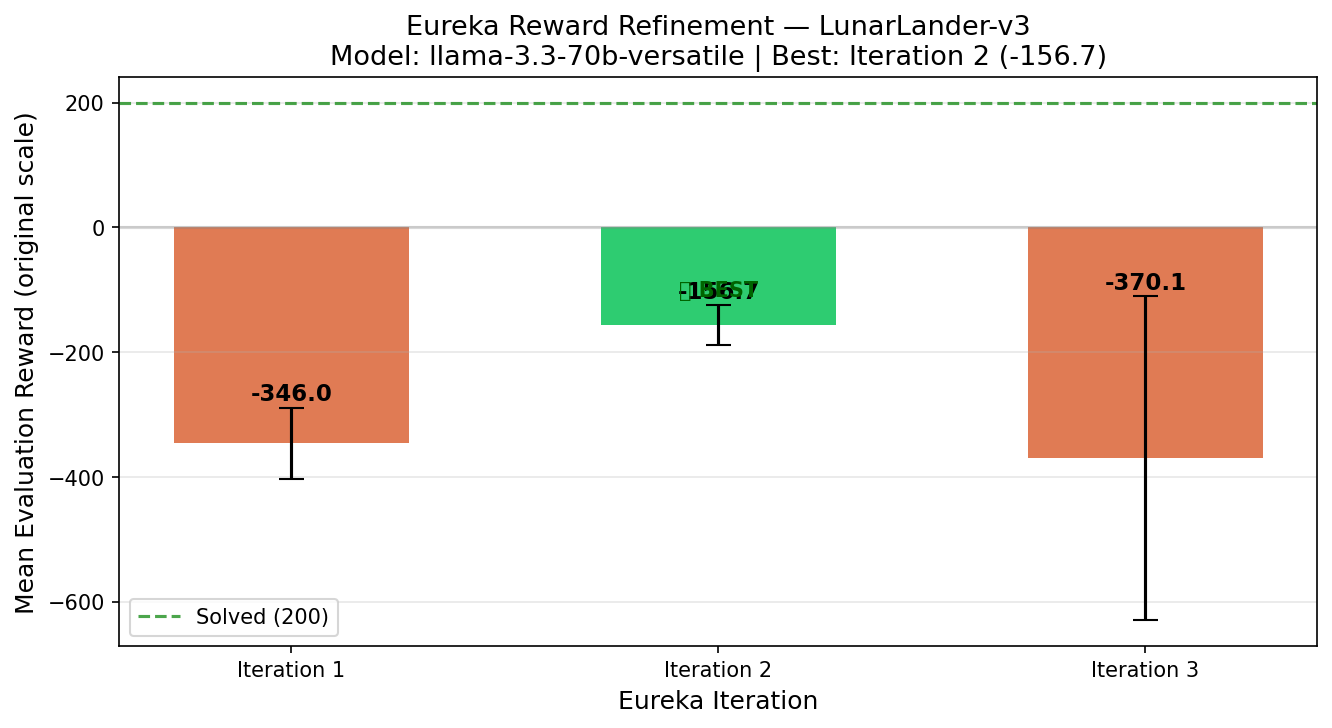

✅ Eureka iteration plot saved → /content/ppo_eureka_results/plots/eureka_iterations.png


In [14]:
iterations = [r['iteration'] for r in eureka_results]
scores     = [r['score']     for r in eureka_results]
stds       = [r['std']       for r in eureka_results]

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#e07b54' if s != best_result['score'] else '#2ecc71' for s in scores]
bars   = ax.bar(iterations, scores, color=colors, width=0.55,
                yerr=stds, capsize=6, error_kw={'linewidth': 1.5})

ax.axhline(y=200, color='green', linestyle='--', alpha=0.7, label='Solved (200)')
ax.axhline(y=0,   color='gray',  linestyle='-',  alpha=0.3)

for bar, score, std in zip(bars, scores, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 4,
        f'{score:.1f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Eureka Iteration', fontsize=12)
ax.set_ylabel('Mean Evaluation Reward (original scale)', fontsize=12)
ax.set_title(
    f'Eureka Reward Refinement — LunarLander-v3\n'
    f'Model: {CONFIG["grok_model"]} | Best: Iteration {best_result["iteration"]} ({best_result["score"]:.1f})',
    fontsize=13
)
ax.set_xticks(iterations)
ax.set_xticklabels([f'Iteration {i}' for i in iterations])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Annotate best bar
best_bar = bars[best_result['iteration'] - 1]
ax.annotate(
    '⭐ BEST',
    xy=(best_bar.get_x() + best_bar.get_width() / 2,
        best_result['score'] + best_result['std'] + 15),
    ha='center', fontsize=10, color='darkgreen', fontweight='bold'
)

plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'eureka_iterations.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
ipy_display(Image(filename=plot_path, width=900))
print(f'✅ Eureka iteration plot saved → {plot_path}')

## 🖨️ Step 12: Display the Best Reward Function

This is a key talking point for your assignment — showing what the LLM actually wrote.

In [15]:
print('\n' + '='*65)
print(f'  🏆 BEST REWARD FUNCTION (Iteration {best_result["iteration"]})')
print(f'  Score: {best_result["score"]:.2f} ± {best_result["std"]:.2f}')
print('='*65)
print(best_code)
print('='*65)


  🏆 BEST REWARD FUNCTION (Iteration 2)
  Score: -156.67 ± 31.67
def compute_reward(obs, action, next_obs, terminated, truncated, info) -> float:
    # Stronger position-based shaping to guide the agent towards the pad
    distance_reward = -0.2 * (np.abs(next_obs[0]) + 2 * np.abs(next_obs[1]))

    # Reward for slowing down as it approaches the pad
    velocity_reward = -0.1 * (np.abs(next_obs[2]) + np.abs(next_obs[3]))

    # Reward for staying upright
    angle_reward = -0.2 * np.abs(next_obs[4])

    # Reward for making leg contact with the ground
    leg_contact_reward = 1.0 * (next_obs[6] + next_obs[7])

    # Penalty for wasting fuel
    fuel_penalty = -0.05 if action != 0 else 0

    # Penalty for deviation from the center
    center_deviation_penalty = -0.1 * np.abs(next_obs[0])

    # Landing bonus
    landing_bonus = 280 if terminated and next_obs[6] == 1 and next_obs[7] == 1 and np.abs(next_obs[2]) < 0.1 and np.abs(next_obs[3]) < 0.1 else 0

    # Crash penalty
    crash_pe

## 🏋️ Step 13: Full PPO-Eureka Training

Now we train PPO for the full 1M timesteps using the best Eureka reward function.
Checkpoint GIFs are recorded at episodes: 1, 5, 10, 25, 50, 100, 200, 500.

In [16]:
# ── Compile the best reward function ─────────────────────────────────────────
best_reward_fn, err = compile_reward_fn(best_code)
if best_reward_fn is None:
    print(f'⚠️  Best reward function failed to compile: {err}')
    print('    Falling back to original LunarLander reward for full training.')
else:
    print(f'✅ Best reward function compiled! (Iteration {best_result["iteration"]})')


# ── Checkpoint callback (same as PPO notebook) ────────────────────────────────
class PPOEurekaCheckpointCallback(BaseCallback):
    def __init__(self, checkpoint_episodes, gif_dir, model_dir,
                 config, reward_fn, verbose=1):
        super().__init__(verbose)
        self.checkpoint_episodes = sorted(checkpoint_episodes)
        self.gif_dir             = gif_dir
        self.model_dir           = model_dir
        self.config              = config
        self.reward_fn           = reward_fn
        self.next_checkpoint_idx = 0
        self.episode_count       = 0
        self.episode_rewards     = []
        self.episode_lengths     = []
        self.checkpoint_log      = []
        self._current_ep_reward  = 0.0
        self._current_ep_length  = 0
        self.start_time          = None

    def _on_training_start(self):
        self.start_time = time.time()
        print('\n' + '='*60)
        print('  PPO-Eureka Full Training — LunarLander-v3')
        print('='*60)
        print(f'  Reward function : Eureka Iteration {best_result["iteration"]}')
        print(f'  Total timesteps : {self.config["total_timesteps"]:,}')
        print(f'  Checkpoints at  : {self.checkpoint_episodes}')
        print('='*60 + '\n')

    def _on_step(self) -> bool:
        self._current_ep_reward += self.locals['rewards'][0]
        self._current_ep_length += 1

        if self.locals['dones'][0]:
            self.episode_count += 1
            ep_reward = self._current_ep_reward
            ep_length = self._current_ep_length

            self.episode_rewards.append({
                'episode' : self.episode_count,
                'timestep': self.num_timesteps,
                'reward'  : round(ep_reward, 2)
            })
            self.episode_lengths.append({
                'episode' : self.episode_count,
                'timestep': self.num_timesteps,
                'length'  : ep_length
            })
            self._current_ep_reward = 0.0
            self._current_ep_length = 0

            if self.next_checkpoint_idx < len(self.checkpoint_episodes):
                target_ep = self.checkpoint_episodes[self.next_checkpoint_idx]
                if self.episode_count >= target_ep:
                    self._save_checkpoint(target_ep, ep_reward)
                    self.next_checkpoint_idx += 1

            if self.episode_count % 10 == 0:
                elapsed = time.time() - self.start_time
                recent  = [r['reward'] for r in self.episode_rewards[-10:]]
                print(
                    f'  Ep {self.episode_count:>4} | '
                    f'Step {self.num_timesteps:>8,} | '
                    f'Last: {ep_reward:>8.1f} | '
                    f'Mean-10: {np.mean(recent):>8.1f} | '
                    f'{elapsed/60:.1f}m'
                )
        return True

    def _save_checkpoint(self, target_ep, last_reward):
        print(f'\n  📸 CHECKPOINT — Episode {target_ep} | Step {self.num_timesteps:,}')
        gif_filename = f'ppo_eureka_episode_{target_ep:04d}.gif'
        gif_path     = os.path.join(self.gif_dir, gif_filename)
        gif_reward, gif_steps = record_gif(
            model     = self.model,
            reward_fn = self.reward_fn,
            gif_path  = gif_path,
            config    = self.config
        )
        model_path = os.path.join(
            self.model_dir, f'ppo_eureka_checkpoint_ep{target_ep:04d}'
        )
        self.model.save(model_path)
        entry = {
            'episode'           : target_ep,
            'actual_episode'    : self.episode_count,
            'timestep'          : self.num_timesteps,
            'gif_episode_reward': round(gif_reward, 2),
            'gif_steps'         : gif_steps,
            'gif_path'          : gif_path,
            'model_path'        : model_path + '.zip'
        }
        self.checkpoint_log.append(entry)
        print(f'     GIF: {gif_filename} (reward: {gif_reward:.1f}) | Model saved')

    def _on_training_end(self):
        elapsed = time.time() - self.start_time
        print('\n' + '='*60)
        print(f'  ✅ PPO-Eureka Training Complete!')
        print(f'  Total episodes  : {self.episode_count}')
        print(f'  Total timesteps : {self.num_timesteps:,}')
        print(f'  Time elapsed    : {elapsed/60:.1f} minutes')
        if self.episode_rewards:
            recent = [r['reward'] for r in self.episode_rewards[-50:]]
            print(f'  Final mean reward (last 50): {np.mean(recent):.1f}')
        print('='*60)


# ── Run full training ─────────────────────────────────────────────────────────
train_env = make_vec_env(best_reward_fn, CONFIG['seed'])
model     = make_ppo(train_env, CONFIG)

print(f'✅ PPO-Eureka model ready on device: {model.device}')

callback = PPOEurekaCheckpointCallback(
    checkpoint_episodes = CONFIG['checkpoint_episodes'],
    gif_dir             = GIF_DIR,
    model_dir           = MODEL_DIR,
    config              = CONFIG,
    reward_fn           = best_reward_fn
)

model.learn(
    total_timesteps = CONFIG['total_timesteps'],
    callback        = callback,
    progress_bar    = False
)

✅ Best reward function compiled! (Iteration 2)
✅ PPO-Eureka model ready on device: cpu

  PPO-Eureka Full Training — LunarLander-v3
  Reward function : Eureka Iteration 2
  Total timesteps : 1,000,000
  Checkpoints at  : [5, 25, 100, 300, 500, 750, 1000, 1500, 2000, 2500]


  📸 CHECKPOINT — Episode 5 | Step 445


/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


     GIF: ppo_eureka_episode_0005.gif (reward: -824.8) | Model saved
  Ep   10 | Step      847 | Last:    -55.1 | Mean-10:   -175.2 | 0.1m
  Ep   20 | Step    1,865 | Last:   -220.4 | Mean-10:   -206.8 | 0.1m

  📸 CHECKPOINT — Episode 25 | Step 2,281
     GIF: ppo_eureka_episode_0025.gif (reward: -824.8) | Model saved
  Ep   30 | Step    2,745 | Last:   -294.2 | Mean-10:   -244.0 | 0.2m
  Ep   40 | Step    3,621 | Last:   -228.3 | Mean-10:   -196.0 | 0.2m
  Ep   50 | Step    4,504 | Last:   -212.5 | Mean-10:   -171.4 | 0.2m
  Ep   60 | Step    5,545 | Last:   -237.6 | Mean-10:   -214.6 | 0.3m
  Ep   70 | Step    6,446 | Last:   -270.1 | Mean-10:   -136.5 | 0.3m
  Ep   80 | Step    7,350 | Last:   -231.2 | Mean-10:   -200.5 | 0.3m
  Ep   90 | Step    8,236 | Last:   -295.2 | Mean-10:   -218.0 | 0.3m

  📸 CHECKPOINT — Episode 100 | Step 9,113
     GIF: ppo_eureka_episode_0100.gif (reward: -500.0) | Model saved
  Ep  100 | Step    9,113 | Last:    -29.0 | Mean-10:   -161.2 | 0.4m
  Ep  11

## 💾 Step 14: Save Final Model & Metrics

In [18]:
# Final model
final_model_path = os.path.join(MODEL_DIR, 'ppo_eureka_final')
model.save(final_model_path)
print(f'✅ Final model saved → {final_model_path}.zip')

# Metrics JSON
metrics = {
    'algorithm'        : 'PPO-Eureka',
    'env_id'           : CONFIG['env_id'],
    'reward_type'      : 'llm_generated',
    'grok_model'     : CONFIG['grok_model'],
    'eureka_iterations': CONFIG['eureka_iterations'],
    'best_iteration'   : best_result['iteration'],
    'best_eureka_score': best_result['score'],
    'total_timesteps'  : CONFIG['total_timesteps'],
    'total_episodes'   : callback.episode_count,
    'config'           : CONFIG,
    'episode_rewards'  : callback.episode_rewards,
    'episode_lengths'  : callback.episode_lengths,
    'checkpoints'      : callback.checkpoint_log,
    'eureka_loop'      : eureka_results,
    'token_usage'      : TOKEN_USAGE
}

metrics_path = os.path.join(METRICS_DIR, 'ppo_eureka_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, cls=NumpyEncoder)

print(f'✅ Metrics saved → {metrics_path}')

✅ Final model saved → /content/ppo_eureka_results/models/ppo_eureka_final.zip
✅ Metrics saved → /content/ppo_eureka_results/metrics/ppo_eureka_metrics.json


## 📈 Step 15: Plot Training Curves

✅ Training curves saved → /content/ppo_eureka_results/plots/ppo_eureka_training_curves.png


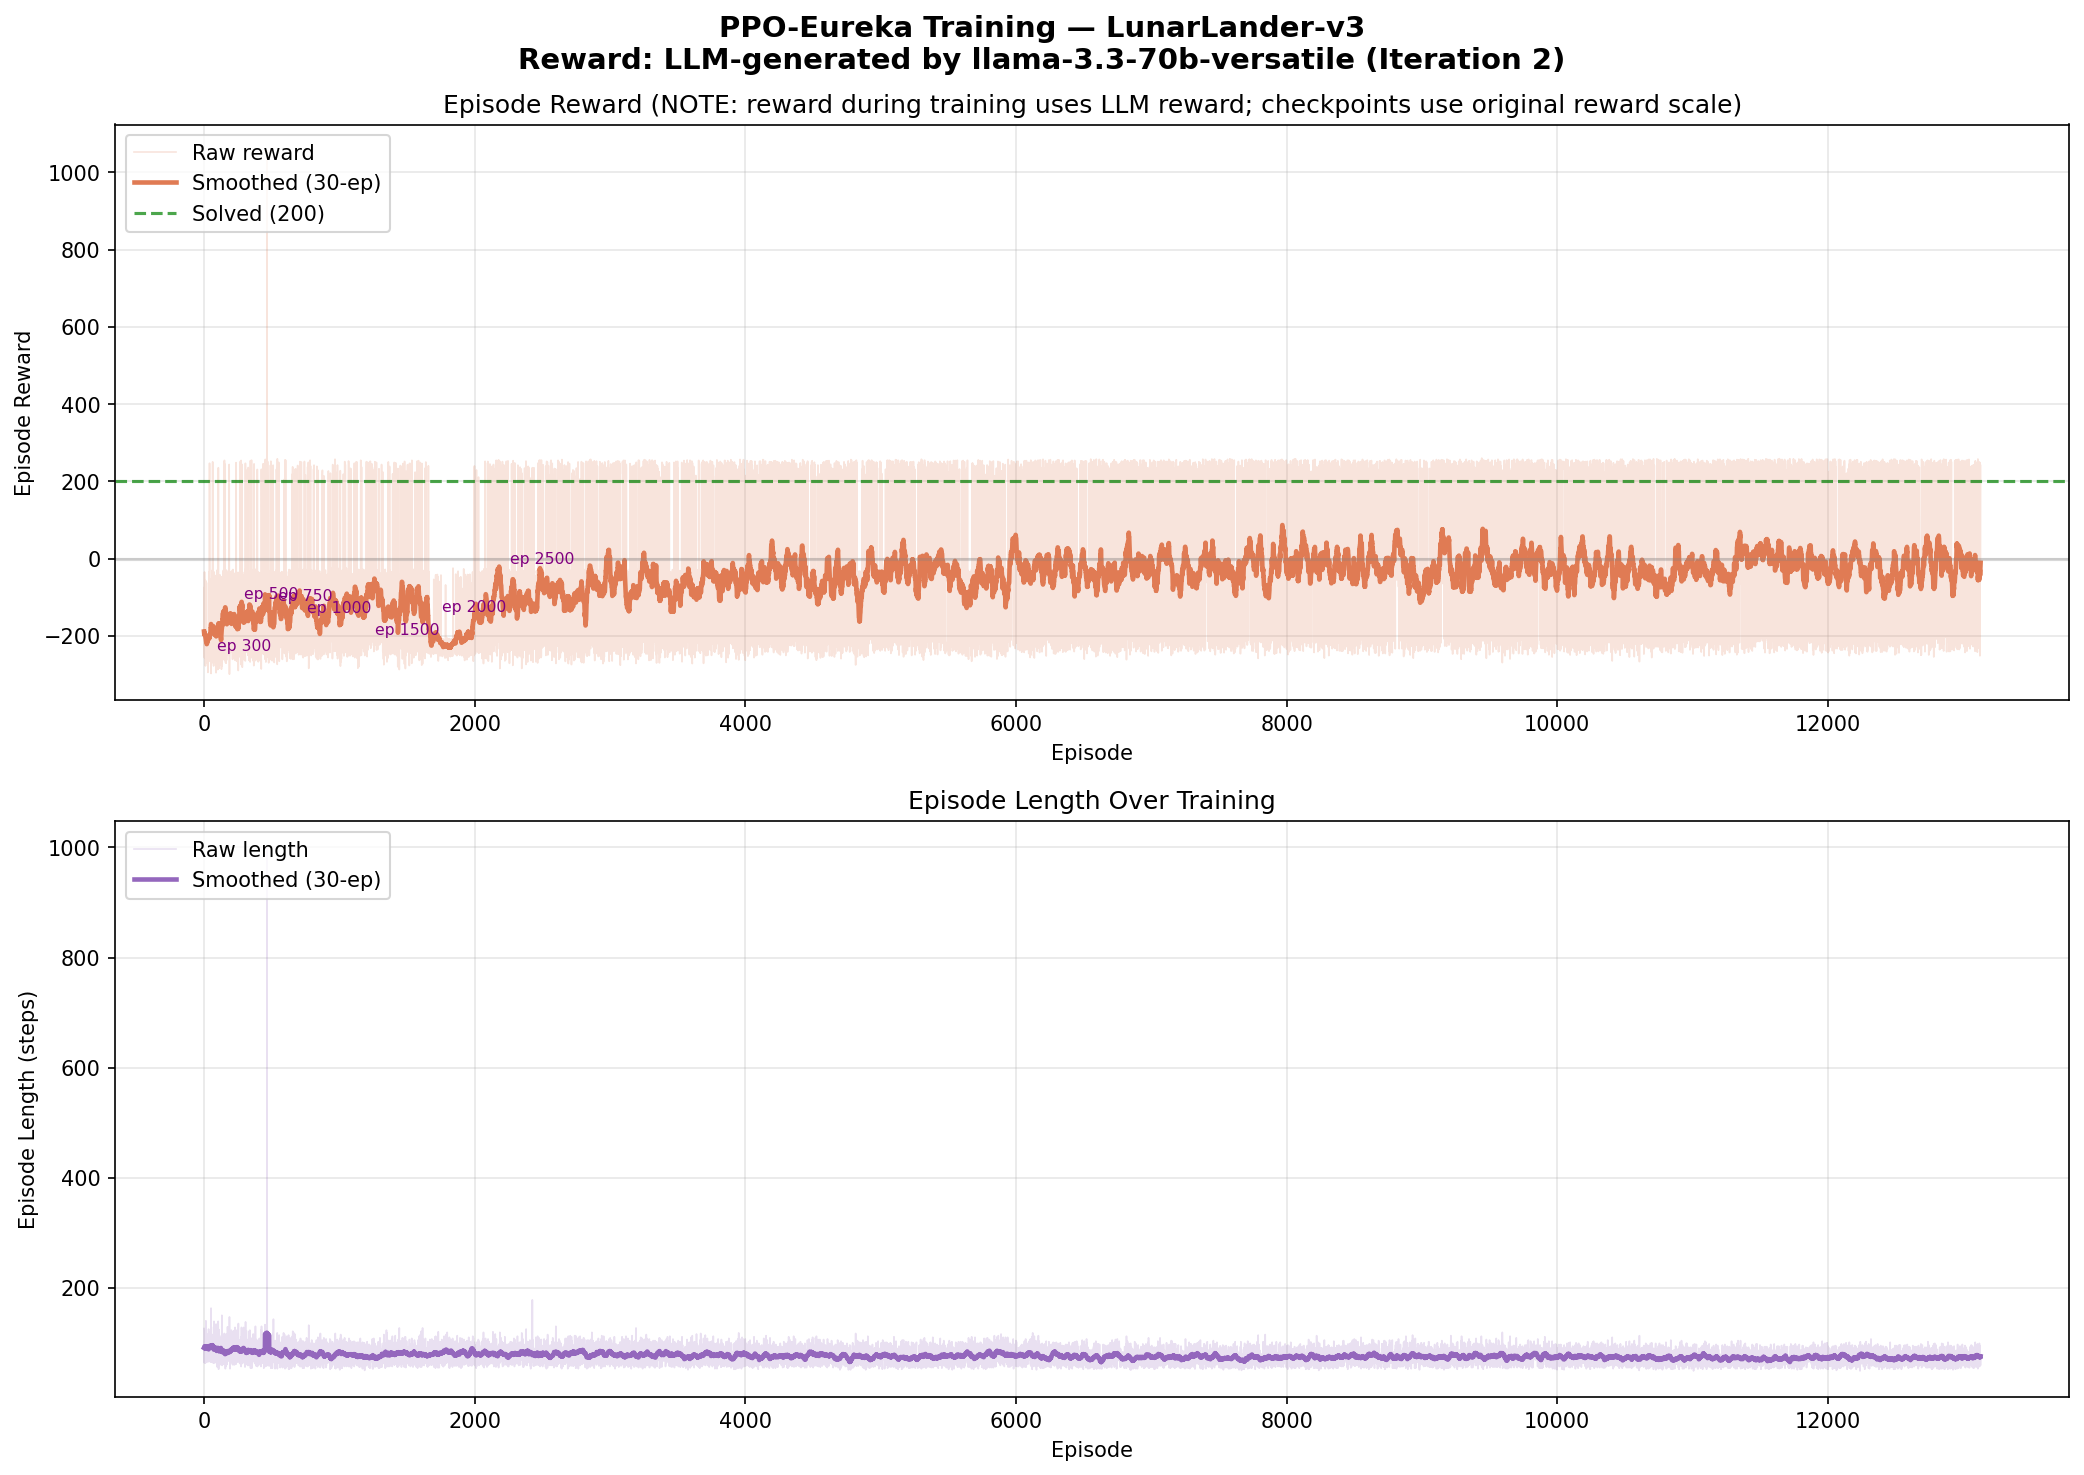

In [21]:
def smooth(values, window=20):
    if len(values) < window:
        return values
    result = []
    for i in range(len(values)):
        start = max(0, i - window // 2)
        end   = min(len(values), i + window // 2 + 1)
        result.append(np.mean(values[start:end]))
    return result


episodes  = [r['episode']  for r in callback.episode_rewards]
rewards   = [r['reward']   for r in callback.episode_rewards]
lengths   = [l['length']   for l in callback.episode_lengths]

ck_eps    = [c['actual_episode']     for c in callback.checkpoint_log]
ck_rws    = [c['gif_episode_reward'] for c in callback.checkpoint_log]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(
    f'PPO-Eureka Training — LunarLander-v3\n'
    f'Reward: LLM-generated by {CONFIG["grok_model"]} (Iteration {best_result["iteration"]})',
    fontsize=14, fontweight='bold'
)

ax1 = axes[0]
ax1.plot(episodes, rewards, alpha=0.2, color='#e07b54', linewidth=0.8, label='Raw reward')
ax1.plot(episodes, smooth(rewards, 30), color='#e07b54', linewidth=2.2, label='Smoothed (30-ep)')
# ax1.scatter(ck_eps, ck_rws, color='purple', zorder=5, s=80,
#             label='GIF checkpoints', marker='D')
for ep, rw, ck in zip(ck_eps, ck_rws, callback.checkpoint_log):
    ax1.annotate(f"ep {ck['episode']}", (ep, rw),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=7.5, color='purple')
ax1.axhline(y=200, color='green', linestyle='--', alpha=0.7, label='Solved (200)')
ax1.axhline(y=0,   color='gray',  linestyle='-',  alpha=0.3)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Episode Reward')
ax1.set_title('Episode Reward (NOTE: reward during training uses LLM reward; '
              'checkpoints use original reward scale)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(episodes, lengths, alpha=0.2, color='#9467bd', linewidth=0.8, label='Raw length')
ax2.plot(episodes, smooth(lengths, 30), color='#9467bd', linewidth=2.2, label='Smoothed (30-ep)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Length (steps)')
ax2.set_title('Episode Length Over Training')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, 'ppo_eureka_training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'✅ Training curves saved → {plot_path}')
ipy_display(Image(filename=plot_path, width=900))

## 🎬 Step 16: View All Checkpoint GIFs

🎬 PPO-Eureka checkpoint GIFs

📍 Episode    5 | reward:  -824.8 | steps: 121


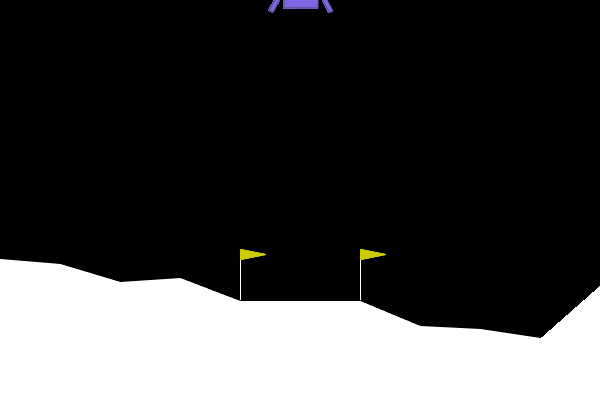

📍 Episode   25 | reward:  -824.8 | steps: 121


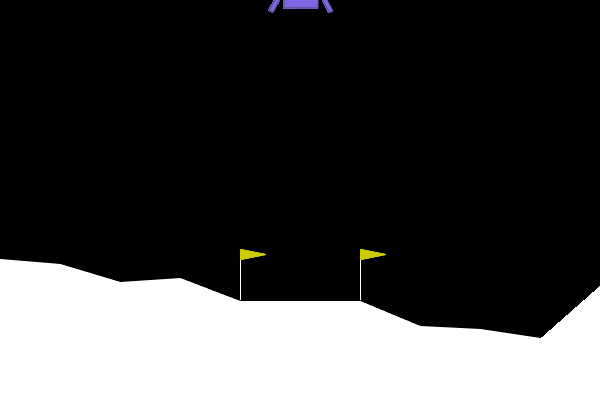

📍 Episode  100 | reward:  -500.0 | steps: 81


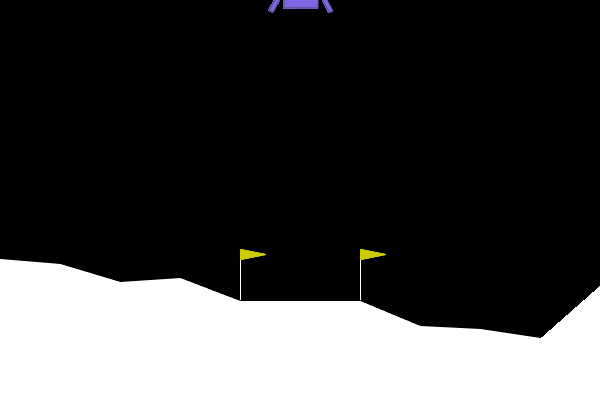

📍 Episode  300 | reward:  -290.9 | steps: 82


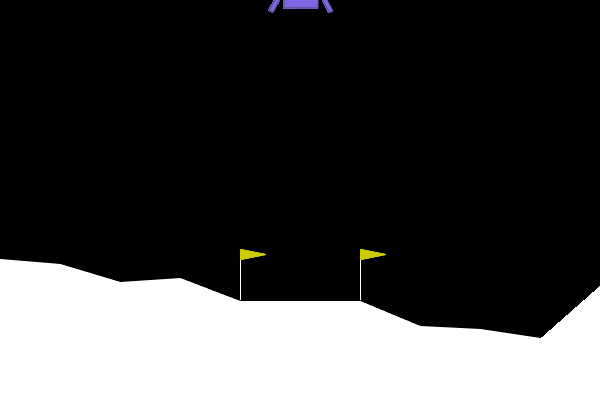

📍 Episode  500 | reward:  -156.0 | steps: 83


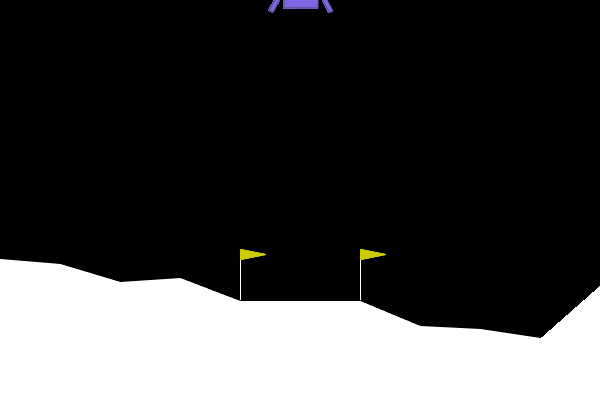

📍 Episode  750 | reward:  -163.4 | steps: 82


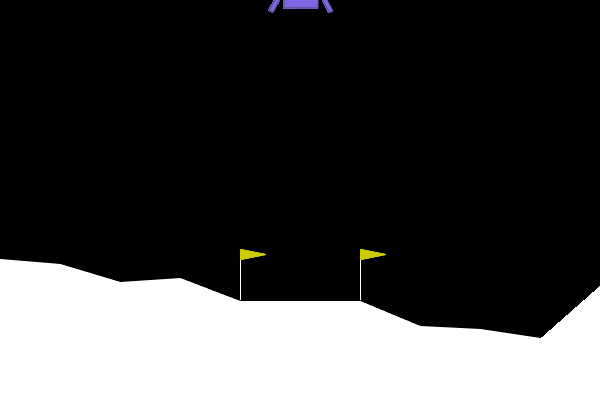

📍 Episode 1000 | reward:  -192.2 | steps: 86


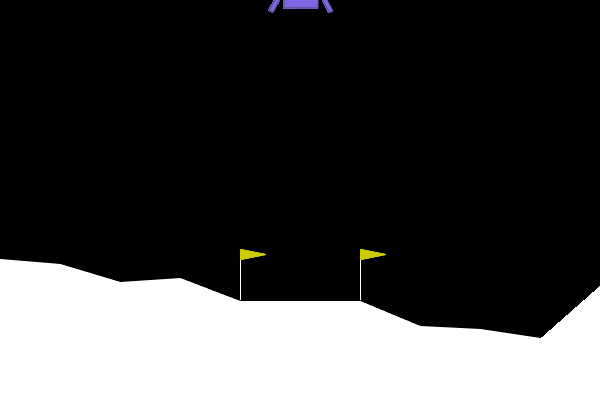

📍 Episode 1500 | reward:  -250.4 | steps: 85


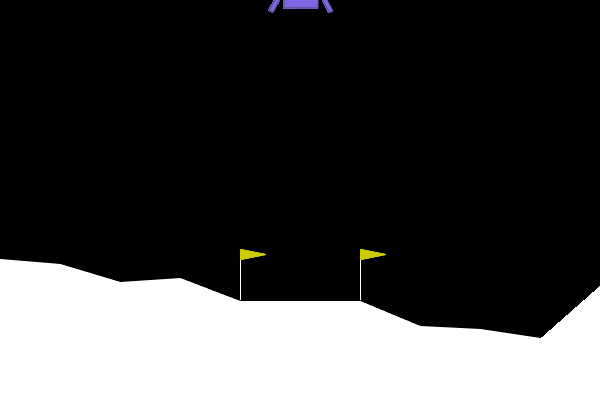

📍 Episode 2000 | reward:  -190.6 | steps: 84


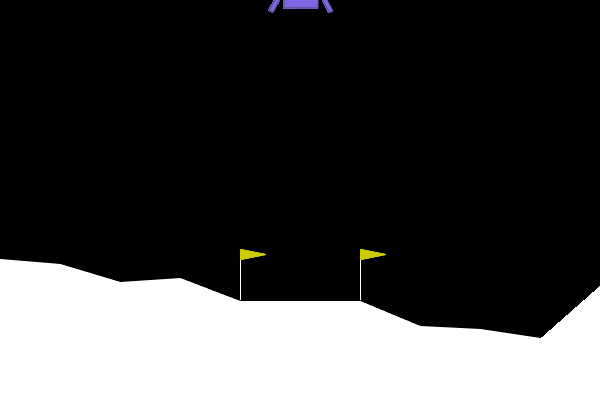

📍 Episode 2500 | reward:   -66.0 | steps: 86


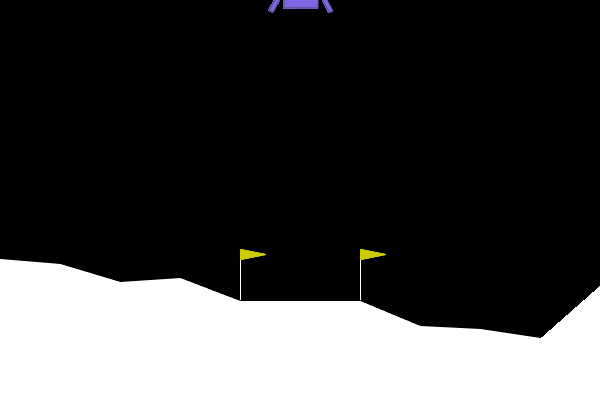

In [22]:
print('🎬 PPO-Eureka checkpoint GIFs\n')
for ck in callback.checkpoint_log:
    ep       = ck['episode']
    reward   = ck['gif_episode_reward']
    steps    = ck['gif_steps']
    gif_path = ck['gif_path']
    print(f'📍 Episode {ep:>4} | reward: {reward:>7.1f} | steps: {steps}')
    if os.path.exists(gif_path):
        ipy_display(Image(filename=gif_path, width=450))
    else:
        print(f'  ⚠️  GIF not found')

## 🏆 Step 17: Final Evaluation

🏆 Final evaluation over 20 episodes (original LunarLander reward)...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



  Final Mean Reward : -125.57 ± 11.43
  Solved threshold  : 200.0
  Status            : ⚠️  Not yet solved

🎬 Final GIF (reward: -131.2)


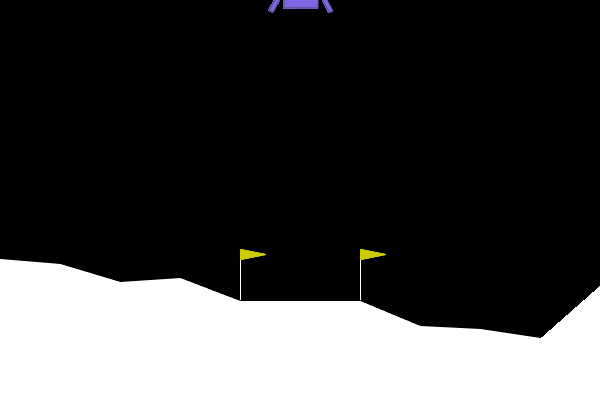

In [23]:
print('🏆 Final evaluation over 20 episodes (original LunarLander reward)...')

eval_env = gym.make(CONFIG['env_id'])
mean_reward, std_reward = evaluate_policy(
    model, eval_env, n_eval_episodes=20, deterministic=True
)
eval_env.close()

print(f'\n  Final Mean Reward : {mean_reward:.2f} ± {std_reward:.2f}')
print(f'  Solved threshold  : 200.0')
status = '✅ SOLVED!' if mean_reward >= 200 else '⚠️  Not yet solved'
print(f'  Status            : {status}')

metrics['final_evaluation'] = {
    'mean_reward': round(mean_reward, 2),
    'std_reward' : round(std_reward, 2),
    'n_episodes' : 20,
    'solved'     : bool(mean_reward >= 200)
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2, cls=NumpyEncoder)

# Final GIF
final_gif_path = os.path.join(GIF_DIR, 'ppo_eureka_final.gif')
final_reward, final_steps = record_gif(
    model=model, reward_fn=best_reward_fn,
    gif_path=final_gif_path, config=CONFIG
)
print(f'\n🎬 Final GIF (reward: {final_reward:.1f})')
ipy_display(Image(filename=final_gif_path, width=450))

## 💰 Step 18: API Cost Summary

In [25]:
print('\n' + '='*55)
print('  💰 API COST SUMMARY')
print('='*55)
print(f'  Model           : {CONFIG["grok_model"]}')
print(f'  API calls made  : {TOKEN_USAGE["api_calls"]}')
print(f'  Approx tokens   : {TOKEN_USAGE["output"]:,} (output words)')
print(f'  TOTAL COST      : $0.00')
print('='*55)


  💰 API COST SUMMARY
  Model           : llama-3.3-70b-versatile
  API calls made  : 3
  Approx tokens   : 960 (output words)
  TOTAL COST      : $0.00


## 📦 Step 19: Download Everything

In [26]:
from google.colab import files

zip_path = '/content/ppo_eureka_results'
print('📦 Creating zip archive...')
shutil.make_archive(zip_path, 'zip', '/content', 'ppo_eureka_results')
zip_full = zip_path + '.zip'

size_mb = os.path.getsize(zip_full) / (1024 * 1024)
print(f'   Size: {size_mb:.1f} MB')

print('\n📂 Contents:')
for root, dirs, filenames in os.walk(BASE_DIR):
    level     = root.replace(BASE_DIR, '').count(os.sep)
    indent    = '  ' * level
    subindent = '  ' * (level + 1)
    print(f'{indent}{os.path.basename(root)}/')
    for filename in sorted(filenames):
        fpath = os.path.join(root, filename)
        fsize = os.path.getsize(fpath) / 1024
        print(f'{subindent}{filename}  ({fsize:.0f} KB)')

print('\n⬇️  Downloading...')
files.download(zip_full)

📦 Creating zip archive...
   Size: 2.6 MB

📂 Contents:
ppo_eureka_results/
  reward_functions/
    best.py  (1 KB)
    iteration_01.py  (1 KB)
    iteration_02.py  (1 KB)
    iteration_03.py  (1 KB)
  gifs/
    ppo_eureka_episode_0005.gif  (26 KB)
    ppo_eureka_episode_0025.gif  (26 KB)
    ppo_eureka_episode_0100.gif  (138 KB)
    ppo_eureka_episode_0300.gif  (133 KB)
    ppo_eureka_episode_0500.gif  (138 KB)
    ppo_eureka_episode_0750.gif  (143 KB)
    ppo_eureka_episode_1000.gif  (143 KB)
    ppo_eureka_episode_1500.gif  (146 KB)
    ppo_eureka_episode_2000.gif  (139 KB)
    ppo_eureka_episode_2500.gif  (146 KB)
    ppo_eureka_final.gif  (131 KB)
  plots/
    eureka_iterations.png  (62 KB)
    ppo_eureka_training_curves.png  (258 KB)
  models/
    ppo_eureka_checkpoint_ep0005.zip  (57 KB)
    ppo_eureka_checkpoint_ep0025.zip  (143 KB)
    ppo_eureka_checkpoint_ep0100.zip  (146 KB)
    ppo_eureka_checkpoint_ep0300.zip  (146 KB)
    ppo_eureka_checkpoint_ep0500.zip  (146 KB)
    ppo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Done!

Your `ppo_eureka_results.zip` contains:

```
ppo_eureka_results/
├── gifs/
│   ├── ppo_eureka_episode_0001.gif
│   ├── ppo_eureka_episode_0005.gif
│   ├── ppo_eureka_episode_0010.gif
│   ├── ppo_eureka_episode_0025.gif
│   ├── ppo_eureka_episode_0050.gif
│   ├── ppo_eureka_episode_0100.gif
│   ├── ppo_eureka_episode_0200.gif
│   ├── ppo_eureka_episode_0500.gif
│   └── ppo_eureka_final.gif
├── models/
│   ├── ppo_eureka_checkpoint_ep*.zip  (one per checkpoint)
│   └── ppo_eureka_final.zip
├── metrics/
│   ├── ppo_eureka_metrics.json   ← all episode rewards + eureka loop data
│   └── eureka_iterations.json    ← score per iteration (for frontend chart)
├── reward_functions/
│   ├── iteration_01.py           ← Claude's first attempt
│   ├── iteration_02.py           ← Revised after feedback
│   ├── iteration_03.py           ← Final refinement
│   └── best.py                   ← Whichever scored highest
└── plots/
    ├── ppo_eureka_training_curves.png
    └── eureka_iterations.png
```

